<a href="https://colab.research.google.com/github/Mariem-mcs/project-recommendation-engine/blob/main/10_learning_curves.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<>:60: SyntaxWarning: invalid escape sequence '\T'
<>:60: SyntaxWarning: invalid escape sequence '\T'
/tmp/ipykernel_5152/2887998725.py:60: SyntaxWarning: invalid escape sequence '\T'
  print(f"\Training with {n_epochs} epochs...")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.8 MB/s eta 0:00:00
All libraries imported!
Loading MovieLens dataset...
Data saved locally
DATA LOADED
Movies: 9,742
Ratings: 100,836
Users: 610

DATA SPLIT READY
Training samples: 80,668
Test samples: 20,168

TRAINING WITH DIFFERENT EPOCHS
\Training with 1 epochs...
  Train RMSE: 0.9221
  Test RMSE:  0.9370
\Training with 5 epochs...
  Train RMSE: 0.8507
  Test RMSE:  0.8960
\Training with 10 epochs...
  Train RMSE: 0.8094
  Test RMSE:  0.8852
\Training with 15 epochs...
  Train RMSE: 0.7676
  Test RMSE:  0.8803
\Training with 20 epochs...
  Train RMSE: 0.7151
  Test RMSE:  0.8775
\Training with 30 epochs...
  Train RMSE: 0.5929
  Test RMSE:  0.8790
\Training with 40 epochs...
  Train RMSE: 0.4899
  Test RMSE:  0.8866
\Training with 50 epochs...
  Train RMSE: 0.4156
  Test RMSE:  0.8942

RESULTS TABLE


,Epochs,Train RMSE,Test RMSE
0,1,0.922075,0.937021
1,5,0.850654,0.895989
2,10,0.809380,0.885211
3,15,0.767591,0.880276
4,20,0.715064,0.877468
5,30,0.592895,0.879025
6,40,0.489890,0.886579
7,50,0.415614,0.894177


Best Test RMSE: 0.8775 at 20 epochs


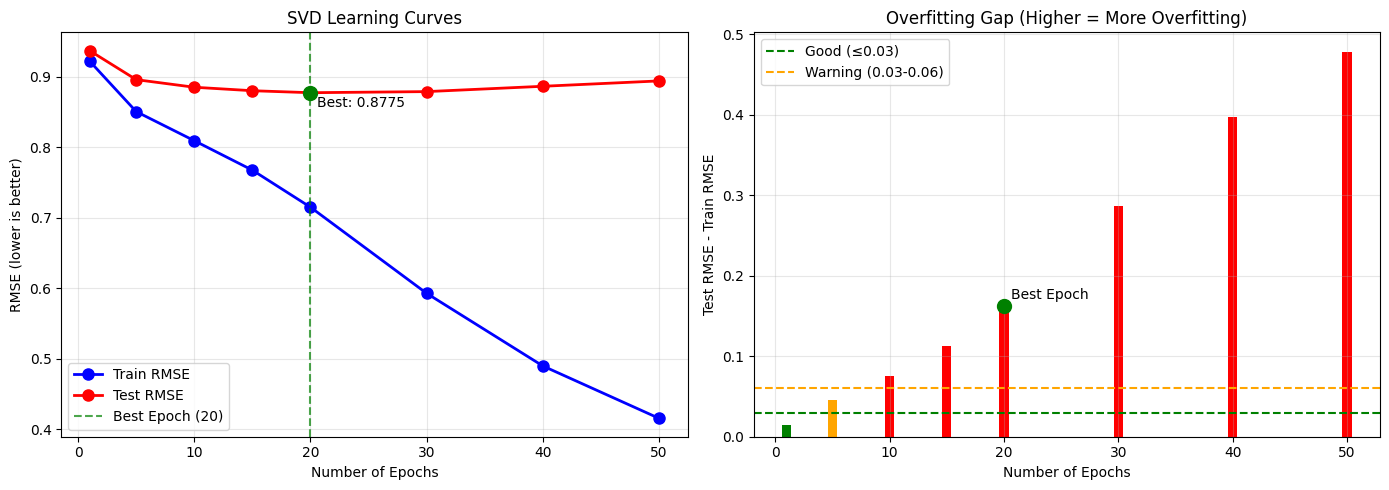


ANALYSIS
KEY FINDINGS:
1. Test RMSE decreases as epochs increase, then starts to flatten:
   - Shows the model is learning from the data
   - Eventually reaches a minimum before overfitting

2. Best Test RMSE: 0.8775 at 20 epochs:
   - This is the optimal number of training iterations
   - Beyond this, the model starts to overfit

3. Overfitting Gap Analysis:

   Epoch 1: Gap=0.0149 - Good
   Epoch 5: Gap=0.0453 - Some overfitting
   Epoch 10: Gap=0.0758 - Significant overfitting
   Epoch 15: Gap=0.1127 - Significant overfitting
   Epoch 20: Gap=0.1624 - Significant overfitting
   Epoch 30: Gap=0.2861 - Significant overfitting
   Epoch 40: Gap=0.3967 - Significant overfitting
   Epoch 50: Gap=0.4786 - Significant overfitting

4. Training vs Test RMSE:
   - Training RMSE continues to decrease (model fits training data)
   - Test RMSE initially decreases, then increases (overfitting)

5. The optimal number of epochs is 20:
   - This is where the model generalizes best
   - Earlier = und

In [1]:
# TODO 8: GENERATING LEARNING CURVES
!pip install scikit-surprise -q

import sys
sys.path.append('.')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import requests
from io import BytesIO
from surprise import Dataset, Reader, SVD
from surprise.model_selection import train_test_split as surprise_train_test_split
print("All libraries imported!")

# 1. Loading the data:
print("Loading MovieLens dataset...")
try:
    movies_df = pd.read_csv('movies.csv')
    ratings_df = pd.read_csv('ratings.csv')
    print("Data loaded from local files")
except FileNotFoundError:
    print("Downloading dataset from GroupLens...")
    url = "http://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
    response = requests.get(url)
    zip_file = zipfile.ZipFile(BytesIO(response.content))
    movies_df = pd.read_csv(zip_file.open('ml-latest-small/movies.csv'))
    ratings_df = pd.read_csv(zip_file.open('ml-latest-small/ratings.csv'))
    movies_df.to_csv('movies.csv', index=False)
    ratings_df.to_csv('ratings.csv', index=False)
    print("Data saved locally")
df = pd.merge(ratings_df, movies_df, on='movieId')
print("=" * 60)
print("DATA LOADED")
print("=" * 60)
print(f"Movies: {movies_df.shape[0]:,}")
print(f"Ratings: {ratings_df.shape[0]:,}")
print(f"Users: {ratings_df['userId'].nunique():,}")

# 2. Preparing the data:
reader = Reader(rating_scale=(0.5, 5.0))
data = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)
trainset, testset = surprise_train_test_split(data, test_size=0.2, random_state=42)
print("\n" + "=" * 60)
print("DATA SPLIT READY")
print("=" * 60)
print(f"Training samples: {sum(1 for _ in trainset.all_ratings()):,}")
print(f"Test samples: {len(testset):,}")

# 3. Training using different epochs:
print("\n" + "=" * 60)
print("TRAINING WITH DIFFERENT EPOCHS")
print("=" * 60)
# Epochs to test:
epochs_range = [1, 5, 10, 15, 20, 30, 40, 50]
train_rmse = []
test_rmse = []
for n_epochs in epochs_range:
    print(f"\Training with {n_epochs} epochs...")

    # Training the model:
    model = SVD(
        n_factors=50,
        n_epochs=n_epochs,
        lr_all=0.005,
        reg_all=0.02,
        random_state=42
    )
    model.fit(trainset)

    # Getting the training predictions:
    train_preds = model.test(trainset.build_testset())
    train_rmse_val = np.sqrt(np.mean([(p.est - p.r_ui)**2 for p in train_preds]))
    train_rmse.append(train_rmse_val)

    # Getting the test predictions:
    test_preds = model.test(testset)
    test_rmse_val = np.sqrt(np.mean([(p.est - p.r_ui)**2 for p in test_preds]))
    test_rmse.append(test_rmse_val)

    print(f"  Train RMSE: {train_rmse_val:.4f}")
    print(f"  Test RMSE:  {test_rmse_val:.4f}")

# 4. Creating the results table:
print("\n" + "=" * 60)
print("RESULTS TABLE")
print("=" * 60)
results_df = pd.DataFrame({
    'Epochs': epochs_range,
    'Train RMSE': train_rmse,
    'Test RMSE': test_rmse
})

# Finding the best epoch:
best_test_rmse = results_df.loc[results_df['Test RMSE'].idxmin()]
best_epoch = int(best_test_rmse['Epochs'])
best_rmse = best_test_rmse['Test RMSE']
display(results_df)
print(f"Best Test RMSE: {best_rmse:.4f} at {best_epoch} epochs")

# 5. Plotting the learning curves:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Learning Curves
ax1 = axes[0]
ax1.plot(epochs_range, train_rmse, 'b-o', label='Train RMSE', linewidth=2, markersize=8)
ax1.plot(epochs_range, test_rmse, 'r-o', label='Test RMSE', linewidth=2, markersize=8)
ax1.axvline(x=best_epoch, color='g', linestyle='--',
            label=f'Best Epoch ({best_epoch})', alpha=0.7)

ax1.set_xlabel('Number of Epochs')
ax1.set_ylabel('RMSE (lower is better)')
ax1.set_title('SVD Learning Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)
# Annotate best point:
ax1.scatter(best_epoch, best_rmse, color='green', s=100, zorder=5)
ax1.annotate(f'Best: {best_rmse:.4f}',
             (best_epoch, best_rmse),
             xytext=(5, -10), textcoords='offset points')

# Plot 2: Overfitting Analysis
ax2 = axes[1]
# Gap between train and test RMSE (positive = overfitting):
gap = [test - train for test, train in zip(test_rmse, train_rmse)]
ax2.bar(epochs_range, gap, color=['green' if g <= 0.03 else 'orange' if g <= 0.06 else 'red' for g in gap])
ax2.axhline(y=0.03, color='g', linestyle='--', label='Good (≤0.03)')
ax2.axhline(y=0.06, color='orange', linestyle='--', label='Warning (0.03-0.06)')
ax2.set_xlabel('Number of Epochs')
ax2.set_ylabel('Test RMSE - Train RMSE')
ax2.set_title('Overfitting Gap (Higher = More Overfitting)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Annotating the best epoch:
ax2.scatter(best_epoch, gap[epochs_range.index(best_epoch)], color='green', s=100, zorder=5)
ax2.annotate(f'Best Epoch',
             (best_epoch, gap[epochs_range.index(best_epoch)]),
             xytext=(5, 5), textcoords='offset points')

plt.tight_layout()
plt.savefig('learning_curves.png')
plt.show()

# 6. Detailed analysis:
print("\n" + "=" * 60)
print("ANALYSIS")
print("=" * 60)
print("""KEY FINDINGS:
1. Test RMSE decreases as epochs increase, then starts to flatten:
   - Shows the model is learning from the data
   - Eventually reaches a minimum before overfitting

2. Best Test RMSE: {:.4f} at {} epochs:
   - This is the optimal number of training iterations
   - Beyond this, the model starts to overfit

3. Overfitting Gap Analysis:
""".format(best_rmse, best_epoch))
for i, (epoch, g) in enumerate(zip(epochs_range, gap)):
    if g <= 0.03:
        status = "Good"
    elif g <= 0.06:
        status = "Some overfitting"
    else:
        status = "Significant overfitting"
    print(f"   Epoch {epoch}: Gap={g:.4f} - {status}")

print("""
4. Training vs Test RMSE:
   - Training RMSE continues to decrease (model fits training data)
   - Test RMSE initially decreases, then increases (overfitting)

5. The optimal number of epochs is {}:
   - This is where the model generalizes best
   - Earlier = underfitting
   - Later = overfitting
""".format(best_epoch))

# 7. Recommendation:
print("\n" + "=" * 60)
print("RECOMMENDATION")
print("=" * 60)
print(f""" Based on the learning curves:
Optimal Epochs: {best_epoch}
Best Test RMSE: {best_rmse:.4f}
Recommendation: Train SVD with {best_epoch} epochs to achieve the best balance
between learning and generalization.
""")

# 8. Saving the results:
results_df.to_csv('learning_curve_results.csv', index=False)
print("Results saved to learning_curve_results.csv")

print("TODO 8 Complete!")